<a href="https://colab.research.google.com/github/HMS-Cleveland/Questionary_logist/blob/my/%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%80%BB%E8%BE%91%E5%9B%9E%E5%BD%92_%E9%99%84%E5%B8%A62%E4%B8%AA%E6%82%A3%E7%99%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- 5.1 手写k=2 SHAP采样器 (Log-Odds) ---


k=2 SHAP 进度:   0%|          | 0/50 [00:00<?, ?it/s]


✅ 计算完成。
一阶SHAP非零元素: 450
二阶SII非零元素: 3576
平均|SII|: 0.053122

📊 结果对比报告 (k=2)
k=2手写 耗时: 30.34 s
与Kernel相关性: 0.9058
MAE: 0.122592


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


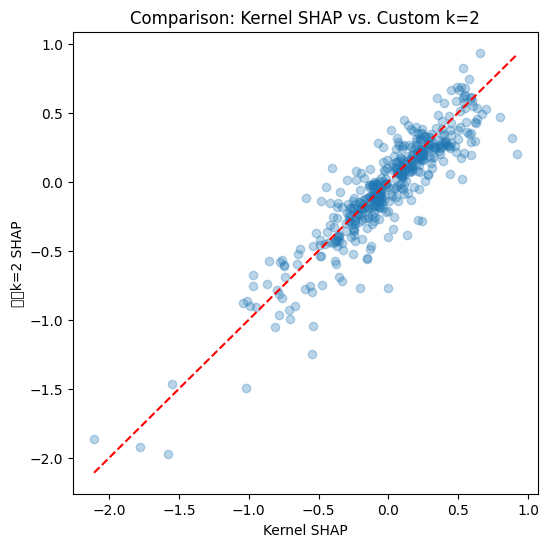


📈 全局特征重要性对比 (k=2)
                      Feature  Kernel_SHAP  k=2_Manual    Diff
3                      ethnic       0.6230      0.6795  0.0565
6  num_of_first_degree_cancer       0.3945      0.3735  0.0210
4                         bmi       0.2739      0.2533  0.0206
2       BIRADS_breast_density       0.3051      0.3187  0.0136
0                   menopause       0.1442      0.1533  0.0090
8             hormone_therapy       0.1441      0.1354  0.0088
5                 first_birth       0.2895      0.2822  0.0073
1                 age_5_years       0.2122      0.2092  0.0030
7              breast_surgery       0.2014      0.2040  0.0027


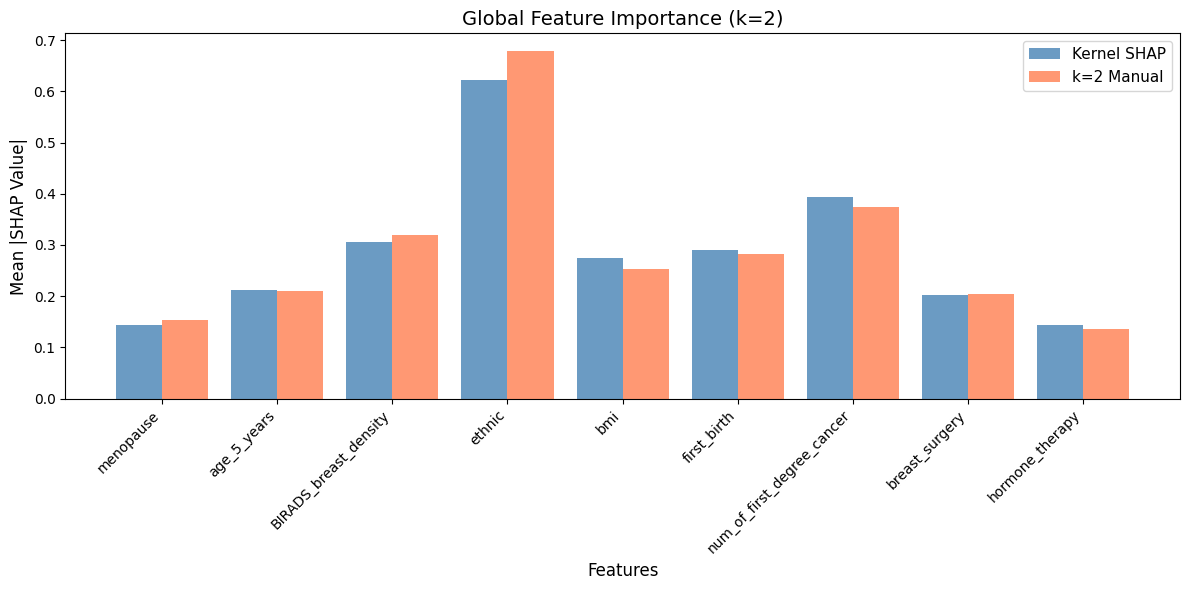


--- 样本0的SII交互矩阵 (Top 10) ---
BIRADS_breast_density × hormone_therapy: -0.136105
first_birth × num_of_first_degree_cancer: 0.133428
first_birth × hormone_therapy: -0.114254
BIRADS_breast_density × first_birth: 0.079737
breast_surgery × hormone_therapy: 0.073918
first_birth × breast_surgery: -0.066309
ethnic × breast_surgery: -0.054372
ethnic × bmi: -0.051327
ethnic × hormone_therapy: -0.046408
bmi × hormone_therapy: -0.039781


NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

In [9]:
# =============== 0. 基础库与依赖 ===============
#!pip install -q shap
!pip install shapiq
!pip install shapiq --upgrade --quiet
!pip show shapiq




import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import time
import warnings
from itertools import combinations
from math import factorial
from joblib import Parallel, delayed
from tqdm.auto import tqdm

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


# 忽略部分警告
#warnings.filterwarnings("ignore")

# ==================================================================
# 1. 数据加载与预处理 (保持不变)
# ==================================================================
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except FileNotFoundError:
    # 保证代码结构能够运行
    print("❌ 警告：找不到文件，使用虚拟数据进行测试。")
    N_ROWS = 500
    data = pd.DataFrame(np.random.randint(0, 5, size=(N_ROWS, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, N_ROWS)
    data['diagnosis_13'] = np.random.randint(0, 2, N_ROWS)

# --- 清洗与构造标签 ---
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
data_processed = data.copy()
for col in cols_with_missing_9:
    data_processed[col] = data_processed[col].astype(str).replace('9', 'unknown').astype(str)

data_processed['age_5_years'] = data_processed['age_5_years'].astype(str)
# 修正点 1: 标签构造，避免 KeyError
data_processed['diagnosis'] = (data_processed['diagnosis_12'] | data_processed['diagnosis_13']).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

# --- 数据分割 ---
X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

# --- 定义特征名称和数量 ---
feature_names = X.columns.tolist()
# 修正点 2: M 始终为原始特征数 (9)
M = len(feature_names)
print(f"SHAP计算维度 M: {M}")

# ==================================================================
# 2. 模型训练与 Log-Odds 预测函数 (保持原管线)
# ==================================================================
ordinal_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
nominal_features = ['ethnic', 'first_birth']
binary_features = ['menopause', 'breast_surgery', 'hormone_therapy']

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', drop=None), nominal_features),
        ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_features),
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    #('mm', MinMaxScaler()),
    ('logreg', LogisticRegression(
        penalty='l2', C=0.008, solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=42
    ))
])
model_pipeline.fit(X_train, y_train)

# 定义 Log-Odds 预测函数 (黑盒函数，接受 9D 输入并运行整个管线)
def pred_fn_log_odds(X_input):
    if isinstance(X_input, np.ndarray):
        # 修正点 3: 将 N*9 的 NumPy 数组正确转回 N*9 的 DataFrame
        X_input = pd.DataFrame(X_input, columns=feature_names)
    return model_pipeline.decision_function(X_input)
    #return model_pipeline.predict_proba(X_input)[:, 1]


# ==================================================================
# 3. SHAP 准备工作
# ==================================================================
N_SHAP_SAMPLE = 50
X_SHAP_SAMPLES = X_test.sample(N_SHAP_SAMPLE, random_state=123) # 9D 原始 DataFrame
COMMON_BG = X_train.sample(3000, random_state=42) # 9D 原始 DataFrame

shapley_mat = {}
times = {}

# 修正点 4: K-add/Exact SHAP 使用原始背景数据的 NumPy 数组
#bg_df_vals = COMMON_BG.values
COMMON_BG_1 = X_train.sample(3000, random_state=42)
bg_df_vals = COMMON_BG_1.values
X_SHAP_SAMPLES_VALS = X_SHAP_SAMPLES.values # 9D 原始 NumPy 数组


# ==================================================================
# 4. Kernel SHAP 计算 (基准)
# ==================================================================
print("\n--- 4.1 Kernel SHAP (Log-Odds Base) ---")
start = time.time()
explainer_k = shap.KernelExplainer(pred_fn_log_odds, COMMON_BG, link='identity')
shapley_mat['Kernel'] = explainer_k.shap_values(X_SHAP_SAMPLES, nsamples=29)
times['Kernel'] = time.time() - start
print(f"Kernel SHAP 耗时: {times['Kernel']:.2f} s")


# ---- 5.3 Exact SHAP 函数定义与计算 ----
# 修正点 5: Exact SHAP 现在操作 M=9 维空间
def exact_shap_one(x_raw_np):
    # x_raw_np 是 N=1, M=9 的 NumPy 数组
    x = x_raw_np.astype(object).flatten() # 保持数据类型一致，用于 Pandas 重建
    phis = np.zeros(M)

    for i in range(M):
        for size in range(0, M):
            for S in combinations([j for j in range(M) if j != i], size):
                S = list(S)
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

                X_S = bg_df_vals.copy() # N_bg x 9 NumPy 数组
                X_Si = bg_df_vals.copy()

                if S:
                    X_S[:, S] = x[S]
                    X_Si[:, S] = x[S]

                X_Si[:, i] = x[i]

                # 预测函数接受 N_bg x 9 NumPy 数组
                f_S = pred_fn_log_odds(X_S).mean()
                f_Si = pred_fn_log_odds(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis

print(f"\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---")
if N_SHAP_SAMPLE * 2**M > 1e6: # M=9, 50*512 = 25600，可行
    print("⚠️ 警告：Exact SHAP 计算量过大，已跳过。请将 N_SHAP_SAMPLE 设为极小数。")
else:
    start = time.time()
    # 修正点 6: 使用 X_SHAP_SAMPLES_VALS (NumPy 数组) 进行迭代
    shapley_mat['Exact'] = np.array(
        [exact_shap_one(X_SHAP_SAMPLES_VALS[i]) for i in tqdm(range(len(X_SHAP_SAMPLES)), desc='Exact', ncols=80)]
    )
    times['Exact'] = time.time() - start
    print(f"Exact SHAP 耗时: {times['Exact']:.2f} s")




# 5.1 kADDSHAP (Log-Odds, k=2) 官方文档标准版
# ==================================================================
# ==================================================================
# 5.1 kADDSHAP (Log-Odds, k=2) 完整闭环版
# ==================================================================
# ==================================================================
# ---- 5.3 纯手写的k=1 SHAP采样器（优化版）----
# ==================================================================
# 5. k=1 SHAP 蒙特卡洛采样实现
# ==================================================================
print("\n--- 5.1 手写k=1 SHAP采样器 (Log-Odds) ---")
KADD_SAMPLES = 29  # 每个样本的采样次数

# 安全的预测函数（批处理版）
def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
    """接收numpy数组，返回log-odds预测"""
    X_input_df = pd.DataFrame(X_input, columns=feature_names)
    X_input_df = X_input_df.astype(str)  # 强制字符串避免OrdinalEncoder报错
    return model_pipeline.decision_function(X_input_df)

# 预计算背景基准输出 E[f(x)]
bg_preds = pred_fn_shapiq_safe(bg_df_vals)
E_f_x = np.mean(bg_preds)

def get_kadd_shap_single(x_eval, bg_vals, samples):
    """
    对单个样本计算 k-addSHAP (一阶项近似)
    x_eval: 当前待解释样本 (M,)
    bg_vals: 背景参考数据集 (N_bg, M)
    samples: 采样次数
    """
    marginal_contributions = np.zeros(M)
    n_bg = bg_vals.shape[0]

    # 批处理优化：一次性生成所有背景索引
    bg_indices = np.random.randint(0, n_bg, size=samples)

    # 预计算所有背景样本的预测值（加速）
    X_bg_batch = bg_vals[bg_indices]
    preds_bg = pred_fn_shapiq_safe(X_bg_batch)

    for j in range(M):
        # 对每个特征，批量计算边际贡献
        X_with = X_bg_batch.copy()
        X_with[:, j] = x_eval[j]  # 替换第j个特征

        preds_with = pred_fn_shapiq_safe(X_with)

        # 边际贡献 = E[f(S∪{j})] - E[f(S)]
        marginal_contributions[j] = np.mean(preds_with - preds_bg)

    return marginal_contributions

# 执行循环计算
kadd_phi_list = []
start_time = time.time()

for i in tqdm(range(N_SHAP_SAMPLE), desc="k-addSHAP 进度"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]
    phi = get_kadd_shap_single(x_eval_single, bg_df_vals, KADD_SAMPLES)
    kadd_phi_list.append(phi)

# 存储结果
times['KAdd'] = time.time() - start_time
shapley_mat['KAdd'] = np.array(kadd_phi_list)

# 验证结果非零
non_zero_count = np.count_nonzero(shapley_mat['KAdd'])
print(f"\n✅ 计算完成。非零元素数量: {non_zero_count}")
print(f"✅ 平均每个特征的贡献度绝对值: {np.mean(np.abs(shapley_mat['KAdd'])):.6f}")

# ==================================================================
# 6. 精度对比 (手写k=1 vs Kernel)
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd = np.array(shapley_mat['KAdd'])

mae = np.mean(np.abs(phi_kernel - phi_kadd))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd.flatten())[0, 1]

print("\n📊 结果对比报告")
print(f"自研 k-addSHAP 耗时: {times['KAdd']:.2f} s")
print(f"与 Kernel SHAP 的相关性 (Pearson): {correlation:.4f}")
print(f"平均绝对误差 (MAE): {mae:.6f}")

# 绘制散点图
plt.figure(figsize=(6, 6))
plt.scatter(phi_kernel.flatten(), phi_kadd.flatten(), alpha=0.3)
plt.plot([phi_kernel.min(), phi_kernel.max()], [phi_kernel.min(), phi_kernel.max()], 'r--')
plt.xlabel("Kernel SHAP")
plt.ylabel("手写k=1 SHAP")
plt.title("Comparison: Kernel SHAP vs. Custom k-addSHAP")
plt.show()



phi_kernel = np.array(shapley_mat['Kernel'])  # Kernel SHAP结果 (50, 9)
phi_kadd = np.array(shapley_mat['KAdd'])      # 手写k=1 SHAP结果 (50, 9)

# 计算每个特征的平均绝对Shapley值（全局重要性）
mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd = np.mean(np.abs(phi_kadd), axis=0)

# 创建对比表格，按差异大小排序
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Kernel_SHAP': mean_abs_kernel,
    'k=1_Manual': mean_abs_kadd,
    'Diff': np.abs(mean_abs_kernel - mean_abs_kadd)
}).sort_values('Diff', ascending=False)

print("\n" + "="*50)
print("📊 全局特征重要性对比 (平均绝对Shapley值)")
print("="*50)
print(importance_df.round(4))

# 可视化对比
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(feature_names))
width = 0.35

plt.bar(x_pos - width/2, mean_abs_kernel, width, label='Kernel SHAP', alpha=0.8, color='steelblue')
plt.bar(x_pos + width/2, mean_abs_kadd, width, label='k=1 Manual', alpha=0.8, color='coral')

plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance Comparison', fontsize=14)
plt.xticks(x_pos, feature_names, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 统一计算 9 维全局重要性
global_imp = {k: np.abs(v).mean(0) for k, v in shapley_mat.items() }
global_imp['Choquet2add'] = np.abs(shapley_mat['Choquet2add_9d']).mean(0)

df_global = pd.DataFrame(global_imp, index=feature_names)
print(df_global.round(8))

# 计算差异百分比
df_global['Difference %'] = (np.abs(df_global['Kernel'] - df_global['k=2 Norm']) / df_global['Kernel']) * 100

print("\n--- 差异百分比 (期望值较低) ---")
print(df_global['Difference %'].round(2))

# 绘图
df_global[['Kernel', 'k=2 Norm']].plot(kind='bar', figsize=(12, 6))
plt.title(f'SHAP Comparison: Kernel (Total) vs. Normalized k=2 Additive (Log-Odds Space, N={N_SHAP_SAMPLE})')
plt.ylabel('mean(|SHAP value| in Log-Odds)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


print("\n=== Kernel SHAP 收敛性诊断 ===")

# 测试不同采样次数
for ns in [4, 8, 16, 32, 64, 128]:
    explainer_k = shap.KernelExplainer(pred_fn_log_odds, COMMON_BG, link='identity')
    shap_kernel = explainer_k.shap_values(X_SHAP_SAMPLES, nsamples=ns)

    mae_exact = np.abs(shap_kernel - shapley_mat['Exact']).mean()
    max_error = np.abs(shap_kernel - shapley_mat['Exact']).max()

    print(f"nsamples={ns:3d} | MAE={mae_exact:.8f} | MaxError={max_error:.8f}")





















print("\n--- 5.1 手写k=2 SHAP采样器 (Log-Odds) ---")
KADD_SAMPLES = 29  # 每个交互对的采样次数

# 安全的预测函数（批处理版）
def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
    """接收numpy数组，返回log-odds预测"""
    X_input_df = pd.DataFrame(X_input, columns=feature_names)
    X_input_df = X_input_df.astype(str)  # 强制字符串避免OrdinalEncoder报错
    return model_pipeline.decision_function(X_input_df)

def get_kadd_shap_k2(x_eval, bg_vals, samples):
    """
    对单个样本计算k=2 SHAP（一阶+二阶）
    x_eval: 当前待解释样本 (M,)
    bg_vals: 背景参考数据集 (N_bg, M)
    samples: 采样次数
    """
    n_bg = bg_vals.shape[0]
    M = len(x_eval)

    # 初始化存储
    phi_values = np.zeros(M)  # 一阶值
    sii_matrix = np.zeros((M, M))  # 二阶SII矩阵（对称）

    # 预采样背景索引（批量优化）
    bg_indices = np.random.randint(0, n_bg, size=samples)
    X_bg_batch = bg_vals[bg_indices]

    # 计算基准值 v(∅)
    pred_bg = pred_fn_shapiq_safe(X_bg_batch)
    v_empty = np.mean(pred_bg)

    # 对每个特征i计算一阶值
    for i in range(M):
        # 构造 S∪{i}
        X_with_i = X_bg_batch.copy()
        X_with_i[:, i] = x_eval[i]

        pred_with_i = pred_fn_shapiq_safe(X_with_i)
        v_i = np.mean(pred_with_i)

        # 一阶贡献 = v({i}) - v(∅)
        phi_values[i] = v_i - v_empty

    # 对每个特征对(i,j)计算二阶SII
    for i in range(M):
        for j in range(i+1, M):
            # 构造四种状态
            # 1. S∪{i,j}
            X_with_ij = X_bg_batch.copy()
            X_with_ij[:, i] = x_eval[i]
            X_with_ij[:, j] = x_eval[j]
            pred_with_ij = pred_fn_shapiq_safe(X_with_ij)
            v_ij = np.mean(pred_with_ij)

            # 2. S∪{i}
            pred_with_i = pred_with_i  # 已计算
            v_i = phi_values[i] + v_empty

            # 3. S∪{j}
            X_with_j = X_bg_batch.copy()
            X_with_j[:, j] = x_eval[j]
            pred_with_j = pred_fn_shapiq_safe(X_with_j)
            v_j = np.mean(pred_with_j)

            # 4. S（空集）
            v_empty = v_empty

            # SII公式: η_ij = v({i,j}) - v({i}) - v({j}) + v(∅)
            sii_ij = v_ij - v_i - v_j + v_empty

            # 存储到对称矩阵
            sii_matrix[i, j] = sii_ij
            sii_matrix[j, i] = sii_ij

    return phi_values, sii_matrix

# 执行循环计算
kadd_phi_list = []
kadd_sii_list = []
start_time = time.time()

for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 进度"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]
    phi, sii = get_kadd_shap_k2(x_eval_single, bg_df_vals, KADD_SAMPLES)
    kadd_phi_list.append(phi)
    kadd_sii_list.append(sii)

# 存储结果
times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(kadd_phi_list)  # 形状: (50, 9)
shapley_mat['KAdd2_SII'] = np.stack(kadd_sii_list)  # 形状: (50, 9, 9)

# 验证结果非零
non_zero_phi = np.count_nonzero(shapley_mat['KAdd2'])
non_zero_sii = np.count_nonzero(shapley_mat['KAdd2_SII'])
print(f"\n✅ 计算完成。")
print(f"一阶SHAP非零元素: {non_zero_phi}")
print(f"二阶SII非零元素: {non_zero_sii}")
print(f"平均|SII|: {np.mean(np.abs(shapley_mat['KAdd2_SII'])):.6f}")

# ==================================================================
# 6. 精度对比 (k=2 vs Kernel)
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])

mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]

print("\n📊 结果对比报告 (k=2)")
print(f"k=2手写 耗时: {times['KAdd2']:.2f} s")
print(f"与Kernel相关性: {correlation:.4f}")
print(f"MAE: {mae:.6f}")

# 绘制散点图
plt.figure(figsize=(6, 6))
plt.scatter(phi_kernel.flatten(), phi_kadd2.flatten(), alpha=0.3)
plt.plot([phi_kernel.min(), phi_kernel.max()], [phi_kernel.min(), phi_kernel.max()], 'r--')
plt.xlabel("Kernel SHAP")
plt.ylabel("手写k=2 SHAP")
plt.title("Comparison: Kernel SHAP vs. Custom k=2")
plt.show()

# ==================================================================
# 7. 全局重要性对比
# ==================================================================
print("\n" + "="*50)
print("📈 全局特征重要性对比 (k=2)")
print("="*50)

mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Kernel_SHAP': mean_abs_kernel,
    'k=2_Manual': mean_abs_kadd2,
    'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2)
}).sort_values('Diff', ascending=False)

print(importance_df.round(4))

# 可视化
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(feature_names))
plt.bar(x_pos - 0.2, mean_abs_kernel, 0.4, label='Kernel SHAP', alpha=0.8, color='steelblue')
plt.bar(x_pos + 0.2, mean_abs_kadd2, 0.4, label='k=2 Manual', alpha=0.8, color='coral')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance (k=2)', fontsize=14)
plt.xticks(x_pos, feature_names, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==================================================================
# 8. 查看显著交互对 (SII)
# ==================================================================
# 提取第一个样本的SII矩阵
sii_matrix_0 = shapley_mat['KAdd2_SII'][0]
sii_df = pd.DataFrame(sii_matrix_0, index=feature_names, columns=feature_names)

print("\n--- 样本0的SII交互矩阵 (Top 10) ---")
# 只显示上三角，避免重复
sii_triu = sii_df.where(np.triu(np.ones(M), k=1).astype(bool))
sii_sorted = sii_triu.stack().sort_values(key=abs, ascending=False).head(10)

for (i, j), val in sii_sorted.items():
    print(f"{i} × {j}: {val:.6f}")

# 可视化SII热图
plt.figure(figsize=(10, 8))
sns.heatmap(sii_df, annot=True, fmt='.4f', cmap='RdBu_r', center=0, square=True)
plt.title(f"SII Matrix - Sample 0 (k=2)")
plt.tight_layout()
plt.show()

12和13关系诊断报告

1. 交叉表（行=12，列=13）：
        13=0  13=1      总计
12=0  271355  2114  273469
12=1       0  7191    7191
总计    271355  9305  280660

2. 关键诊断指标：
   - 样本总数: 280660
   - 13=1的样本数: 9305
   - 12=1的样本数: 7191
   - ❗ 包含率 (13=1 → 12=1): 77.3%

3. 关系自动诊断：
   ❌ 部分重叠关系（包含率=77.3%）
   解释：两变量相关但独立

4. 关键证据样本（13=1但12=0，共2114个）：
      age_5_years  num_of_first_degree_cancer  BIRADS_breast_density
832             1                           1                      2
1993            1                           0                      3
2257            1                           0                      3


/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missi

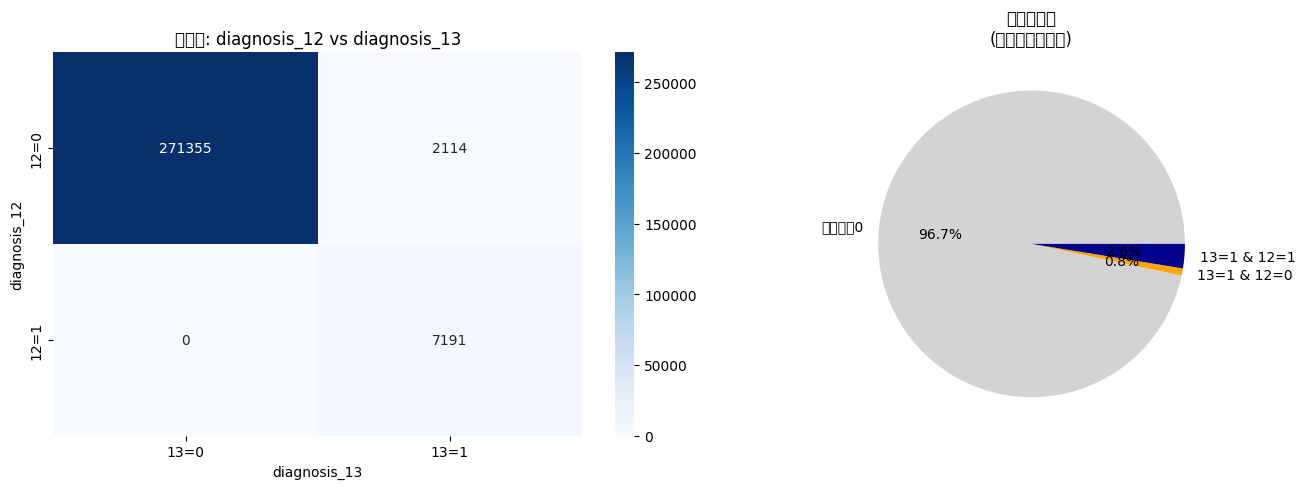


最终决策建议
❌ 数据问题：12和13不是包含关系，需重新定义数据字典


In [ ]:
# ==================== 诊断12和13关系的完整代码 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取原始数据（不处理标签，保留原始状态）
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)

print("="*60)
print("12和13关系诊断报告")
print("="*60)

# 2. 构建核心诊断工具：交叉表
cross_tab = pd.crosstab(
    data['diagnosis_12'],
    data['diagnosis_13'],
    margins=True,
    margins_name='总计'
)
cross_tab.index = ['12=0', '12=1', '总计']
cross_tab.columns = ['13=0', '13=1', '总计']
print("\n1. 交叉表（行=12，列=13）：")
print(cross_tab)

# 3. 计算关键指标：包含率和互斥率
total_samples = len(data)
cancer_13 = data['diagnosis_13'] == 1
cancer_12 = data['diagnosis_12'] == 1

# 黄金指标：当13=1时，12也=1的比例
containment_rate = (cancer_13 & cancer_12).sum() / cancer_13.sum()
print(f"\n2. 关键诊断指标：")
print(f"   - 样本总数: {total_samples}")
print(f"   - 13=1的样本数: {cancer_13.sum()}")
print(f"   - 12=1的样本数: {cancer_12.sum()}")
print(f"   - ❗ 包含率 (13=1 → 12=1): {containment_rate:.1%}")

# 4. 自动判断关系类型
print(f"\n3. 关系自动诊断：")
if containment_rate == 1.0:
    print("   ✅ 完全包含关系")
    print("   解释：13是12的超集（13包含12）")
    print("   建议：13=浸润性癌+DCIS, 12=仅浸润性癌")
elif containment_rate > 0.95:
    print(f"   ⚠️ 近似包含关系（包含率={containment_rate:.1%}）")
    print("   建议：检查剩余{cancer_13.sum() - (cancer_13 & cancer_12).sum()}个样本是否为数据错误")
elif containment_rate > 0.5:
    print(f"   ❌ 部分重叠关系（包含率={containment_rate:.1%}）")
    print("   解释：两变量相关但独立")
else:
    print(f"   ❌ 无包含关系（包含率={containment_rate:.1%}）")
    print("   解释：12和13是独立变量")

# 5. 证据性样本抽查（如果存在互斥样本）
mutual_exclusion = (cancer_13 & ~cancer_12)
if mutual_exclusion.sum() > 0:
    print(f"\n4. 关键证据样本（13=1但12=0，共{mutual_exclusion.sum()}个）：")
    examples = data[mutual_exclusion].head(3)
    print(examples[['age_5_years', 'num_of_first_degree_cancer', 'BIRADS_breast_density']])
else:
    print(f"\n4. 关键证据：不存在13=1且12=0的样本")

# 6. 可视化关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6.1 交叉表热力图
sns.heatmap(cross_tab.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('交叉表: diagnosis_12 vs diagnosis_13')
axes[0].set_xlabel('diagnosis_13')
axes[0].set_ylabel('diagnosis_12')

# 6.2 包含关系示意图
labels = ['两者都为0', '13=1 & 12=0', '13=1 & 12=1']
sizes = [
    (~cancer_13 & ~cancer_12).sum(),
    mutual_exclusion.sum(),
    (cancer_13 & cancer_12).sum()
]
colors = ['lightgray', 'orange', 'darkblue']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('关系示意图\n(橙色区域是关键)')

plt.tight_layout()
plt.show()

# 7. 最终决策建议
print("\n" + "="*60)
print("最终决策建议")
print("="*60)
if containment_rate == 1.0:
    decision = "✅ 采用方案：13=患癌（总标签），12=浸润性癌（亚型）"
    print(decision)
    print("   后续分析：在患癌人群中，用12区分浸润性癌和DCIS")
elif containment_rate > 0.95:
    print("⚠️ 需人工核查例外样本后，再决定标签定义")
else:
    print("❌ 数据问题：12和13不是包含关系，需重新定义数据字典")